In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
import mdp_utils
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from radar import radar_chart


%load_ext autoreload
%autoreload 2

c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\src\env\simulate.py:63: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  user_type = selection if selection is not 'combined' else 'random'
Failed to read module file 'C:\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, l

In [2]:
NUM_VALS_PER_FEATURE = [2, 2, 2]
NUM_FEATURES = len(NUM_VALS_PER_FEATURE)
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 6
MAX_COUNT = 2
NUM_ACTIONS = NUM_CLUSTERS

cluster_col = 'cluster_all'
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Perceived usefulness']
cluster_vars = ['usefulness', 'difficulty', 'time_spent']

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity"]
obj_names = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

NUM_OBJECTIVES = len(reward_cols)

In [3]:
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

action_file = 'challenge_info.csv'
actions = pd.read_csv(data_folder + action_file)

filename = 'processed_samples.csv'
samples = pd.read_csv(os.path.join(data_folder, filename))

In [4]:
def get_cluster_size(df, cluster_vars, cluster_n, min_samples=5):
    """Determine optimal cluster size based on silhouette score and minimum cluster size.
    args:
    - df: DataFrame with z-scores for coping strategy categories.
    - cluster_vars: List of column names to use for clustering.
    - cluster_n: List of integers representing different cluster sizes to evaluate.
    - min_samples: Minimum number of samples required in the smallest cluster.
    returns:
    - best_k: Optimal number of clusters."""
 
    scaler = StandardScaler()
    X = scaler.fit_transform(df[cluster_vars])
    
    sil_scores = []
    smallest_cluster_sizes = []
 
    # calculate silhouette scores for different cluster sizes
    for k in cluster_n:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
 
        sil_scores.append(silhouette_score(X, labels))
 
        # get sample size of smallest cluster
        cluster_counts = pd.Series(labels).value_counts()
        smallest_cluster_sizes.append(cluster_counts.min())
 
    # get optimal cluster n based on silhouette score
    best_k = cluster_n[np.argmax(sil_scores)]
 
    # if smallest cluster size is below min_samples, check other cluster n
    if smallest_cluster_sizes[np.argmax(sil_scores)] < min_samples:
        # get cluster n with largest smallest cluster
        best_k = cluster_n[np.argmax(smallest_cluster_sizes)]

    print(f"Silhouette scores: {sil_scores}")
 
    return best_k

In [5]:
overall_size = get_cluster_size(actions, cluster_vars, cluster_n=range(2, 13), min_samples=1)
print(f"Optimal cluster size: {overall_size}")

for col in cluster_vars:
    best_size = get_cluster_size(actions, [col], cluster_n=range(2, 13), min_samples=1)
    print(f"Optimal cluster size for {col}: {best_size}")

Silhouette scores: [0.28549988533664183, 0.3339231043783242, 0.3011979363139973, 0.31506076793986504, 0.3115595682058796, 0.2676509256667433, 0.3071810954865699, 0.29920829674872285, 0.3066369520916267, 0.30312627312684975, 0.2935306481440842]
Optimal cluster size: 3
Silhouette scores: [0.658917888666504, 0.5914009433162121, 0.5192636797955958, 0.5371471857023882, 0.5507980476444385, 0.5794459575149048, 0.5753785751199602, 0.5465901818227696, 0.5270198040566613, 0.5593005188057546, 0.5410500103890326]
Optimal cluster size for usefulness: 2
Silhouette scores: [0.5688806621601533, 0.5178445646001637, 0.5243954284901401, 0.5345613441189115, 0.5377376679325381, 0.5241480996917913, 0.5314286387681387, 0.5391216893880305, 0.5362094246350865, 0.5410781623994824, 0.5565445506404444]
Optimal cluster size for difficulty: 2
Silhouette scores: [0.7874227139260916, 0.741925622778607, 0.6882004736128493, 0.6479564315574202, 0.6580484065603042, 0.6409752471099565, 0.5844447779860441, 0.59307443382682

In [6]:
actions[cluster_vars + ['expert_score']].corr()

,usefulness,difficulty,time_spent,expert_score
usefulness,1.000000,-0.118284,0.288323,0.094094
difficulty,-0.118284,1.000000,0.225191,0.466103
time_spent,0.288323,0.225191,1.000000,0.081306
expert_score,0.094094,0.466103,0.081306,1.000000


In [7]:
# cluster actions by category and expert score
actions.groupby(['category', 'expert_score']).size().unstack(fill_value=0)
actions['cat_diff_cluster'] = actions.groupby(['category', 'expert_score']).ngroup()

In [8]:
actions.groupby('cat_diff_cluster')[cluster_vars].agg(['mean', 'count'])

usefulness       difficulty       time_spent      
                       mean count       mean count       mean count
cat_diff_cluster                                                   
0                  4.206020     2   2.861204     2   3.582441     2
1                  4.133012     9   3.282582     9   3.720026     9
2                  4.213920    13   3.540012    13   5.584509    13
3                  3.704843     8   1.875281     8   5.579509     8
4                  3.707256    19   2.999948    19   8.920649    19
5                  3.741953     9   3.681989     9  16.526301     9
6                  4.072727     2   2.679545     2  19.263636     2
7                  3.535123     7   2.726588     7   2.813088     7
8                  3.666635    11   3.606242    11   6.012524    11
9                  3.532307     3   2.695954     3   8.577597     3
10                 4.306157    13   3.056039    13  21.528070    13
11                 4.372712     7   3.541645     7  23.524059     7

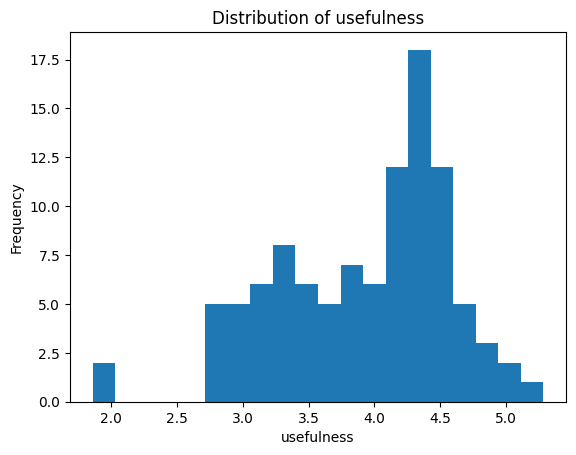

usefulness - Mean: 3.93, Std: 0.66


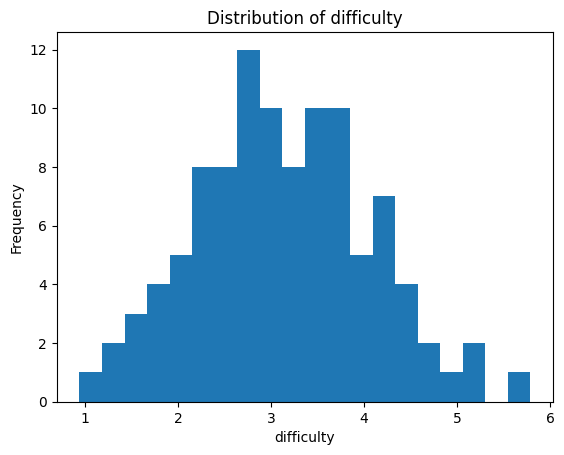

difficulty - Mean: 3.14, Std: 0.94


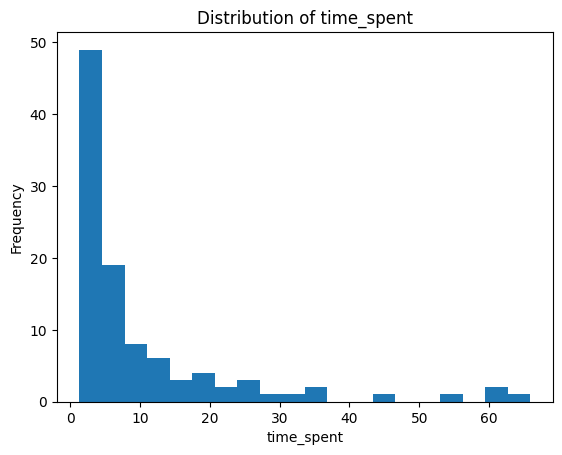

time_spent - Mean: 10.40, Std: 13.21


In [9]:
for var in cluster_vars:
    plt.figure()
    plt.hist(actions[var], bins=20)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()
    # print mean and std
    print(f"{var} - Mean: {actions[var].mean():.2f}, Std: {actions[var].std():.2f}")

In [ ]:
def plot_radar(labels, values, groups, title='Radar Chart'):
    """
    labels: list of strings (column names)
    values: 2D numpy array or list of lists (rows = groups, cols = labels)
    groups: list of strings (cluster/group names)
    """
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for i, row in enumerate(values):
        data = np.concatenate((row, [row[0]]))
        ax.plot(angles, data, linewidth=2, linestyle='solid', label=groups[i], marker='o', markersize=4)
        ax.fill(angles, data, alpha=0.25)
    ax.set_yticklabels([])
    # 5. Fix the labels
    ax.set_theta_offset(np.pi / 2) # Start at the top
    ax.set_theta_direction(-1)     # Clockwise
    
    # Set the labels for each spoke
    ax.tick_params(pad=20)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=14)
    for label in ax.get_xticklabels():
        angle = label.get_position()[0]
        if abs(angle) < 0.1 or abs(angle - 2*np.pi) < 0.1:
            label.set_y(label.get_position()[1] + 0.1)
        elif np.isclose(abs(angle), np.pi):
            label.set_y(label.get_position()[1] + 0.1)

    # Add legend and title
    # plt.title(title, size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    return fig, ax

             usefulness  difficulty  likedness
cluster_all                                   
0              3.086578    3.552140   4.583985
1              4.155860    2.404307   6.305260
2              4.191164    3.988272   5.990499


,usefulness,difficulty,likedness,completion_rate
cluster_all,,,,
0,3.086578,3.552140,4.583985,0.510397
1,4.155860,2.404307,6.305260,0.709478
2,4.191164,3.988272,5.990499,0.569339


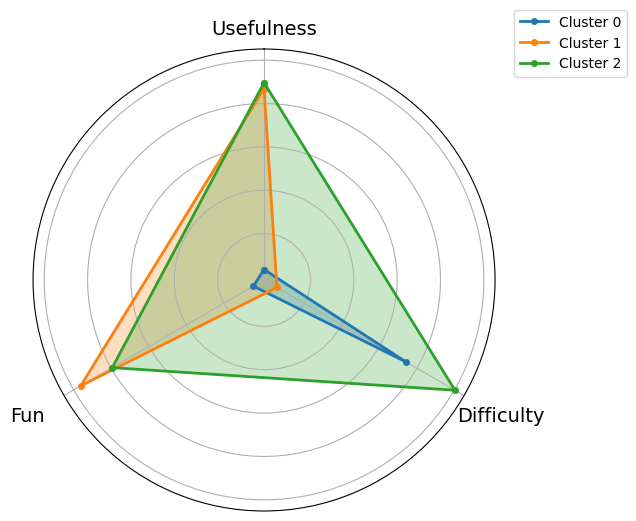

In [22]:
num_clusters = 3
cluster_vars = ['usefulness', 'difficulty', 'likedness']
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
print(means)
# for cluster in range(num_clusters):
#     print(f"Cluster {cluster}:")
#     print(means.loc[cluster])
#     actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
#     print(actions_in_cluster['challenge_id'].tolist())
#     print(actions_in_cluster.groupby('category').size())
means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Fun'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')
# plt.show()
plt.savefig(results_folder + "figures/cluster_radar_chart.svg", bbox_inches='tight')
actions_clustered.groupby(cluster_col)[cluster_vars + ['completion_rate']].mean()

In [12]:
# Take states into account when clustering
df, _, _ = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE)
# print nr of samples per (s,a) pair
df.groupby(['s_idx', cluster_col]).size().unstack(fill_value=0)


cluster_all,0,1,2
s_idx,,,
0,208,450,342
1,63,107,92
2,65,139,90
3,79,164,113
4,174,374,200
5,25,50,42
6,36,86,68
7,34,61,49


In [13]:
df.groupby('challenge_id').size()

challenge_id
AC1     24
AC10    34
AC11    27
AC12    37
AC13    36
        ..
SP5     22
SP6     29
SP7     31
SP8     26
SP9     28
Length: 103, dtype: int64